In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
# Load the dataset
data = pd.read_csv("C:/Users/satra/Downloads/Supermart Grocery Sales - Retail Analytics Dataset.csv")

# Display the first few rows
data.head()


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [5]:
# Check for missing values
print(data.isnull().sum())

# Drop rows with missing values (if any)
data.dropna(inplace=True)

# Drop duplicate rows
data.drop_duplicates(inplace=True)

# Check the shape after cleaning
print(data.shape)


Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64
(9994, 11)


In [7]:
# Convert 'Order Date' to datetime format
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')

# Extract day, month, and year from 'Order Date'
data['Order Day'] = data['Order Date'].dt.day
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year


In [9]:
# Initialize LabelEncoder
le = LabelEncoder()

# Encode categorical columns
for col in ['Category', 'Sub Category', 'City', 'Region', 'State', 'Month']:
    if col in data.columns:
        data[col] = le.fit_transform(data[col])


In [11]:
data.info()
data.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Customer Name  9994 non-null   object        
 2   Category       9994 non-null   int32         
 3   Sub Category   9994 non-null   int32         
 4   City           9994 non-null   int32         
 5   Order Date     4042 non-null   datetime64[ns]
 6   Region         9994 non-null   int32         
 7   Sales          9994 non-null   int64         
 8   Discount       9994 non-null   float64       
 9   Profit         9994 non-null   float64       
 10  State          9994 non-null   int32         
 11  Order Day      4042 non-null   float64       
 12  Order Month    4042 non-null   float64       
 13  Order Year     4042 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int32(5), int64(1), object(2)
memory u

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Order Day,Order Month,Order Year
0,OD1,Harish,5,14,21,2017-11-08,2,1254,0.12,401.28,0,8.0,11.0,2017.0
1,OD2,Sudha,1,13,8,2017-11-08,3,749,0.18,149.80,0,8.0,11.0,2017.0
2,OD3,Hussain,3,0,13,2017-06-12,4,2360,0.21,165.20,0,12.0,6.0,2017.0
3,OD4,Jackson,4,12,4,2016-10-11,3,896,0.25,89.60,0,11.0,10.0,2016.0
4,OD5,Ridhesh,3,18,12,2016-10-11,3,2355,0.26,918.45,0,11.0,10.0,2016.0


C:\Users\satra\AppData\Local\Temp\ipykernel_13884\71505182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Sales', data=data, palette='Set2')


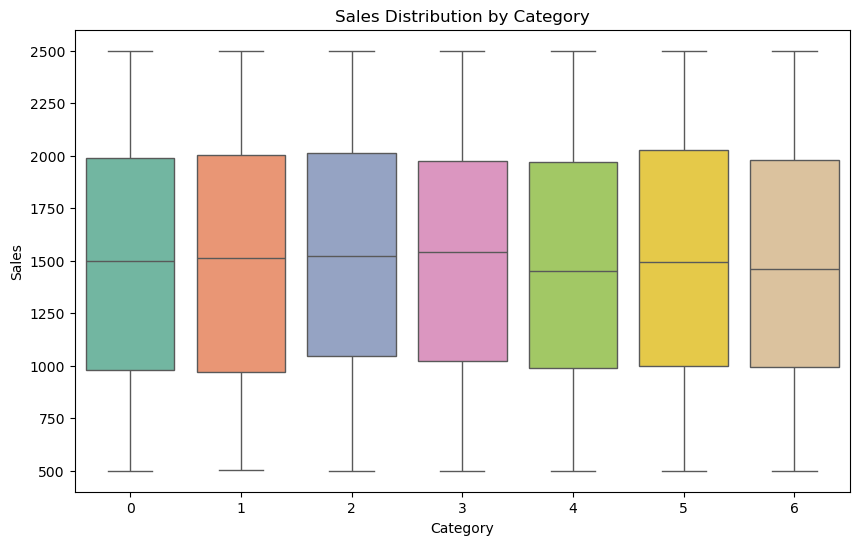

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Sales', data=data, palette='Set2')
plt.title('Sales Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()


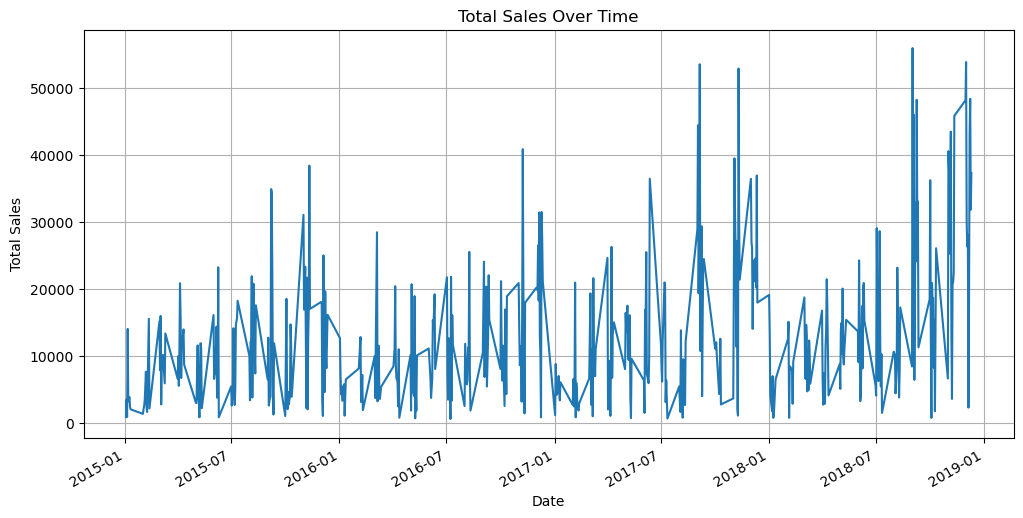

In [15]:
plt.figure(figsize=(12, 6))
data.groupby('Order Date')['Sales'].sum().plot()
plt.title('Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()


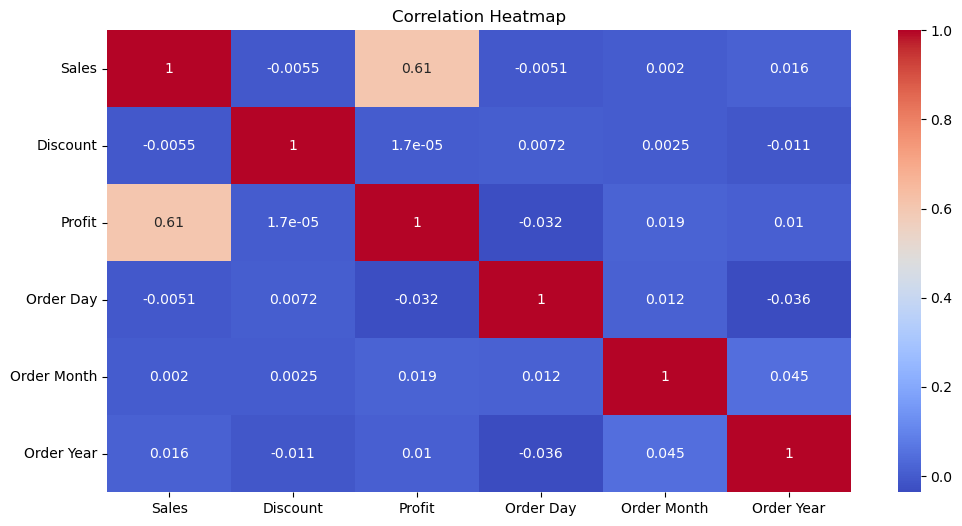

In [21]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Plot correlation heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [27]:
# Drop only the columns that exist
columns_to_drop = ['Order ID', 'Customer Name', 'Order Date', 'Sales', 'Month']
columns_to_drop = [col for col in columns_to_drop if col in data.columns]

# Define features and target
features = data.drop(columns=columns_to_drop)
target = data['Sales']


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [41]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create an imputer to replace NaN values with the mean
imputer = SimpleImputer(strategy='mean')

# Apply the imputer to your training and test data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Fit the model on the imputed data
model.fit(X_train_imputed, y_train)

# Make predictions
y_pred = model.predict(X_test_imputed)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r2}")


Mean Absolute Error (MAE): 379.0663474933052
Mean Squared Error (MSE): 212753.66007996202
R-squared: 0.3549334514756759


In [45]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Use Ridge regression (regularized Linear Regression)
ridge_model = Ridge()

# Define parameter grid for Ridge regression
param_grid = {
    'alpha': [0.1, 1, 10, 100]  # Alpha controls the regularization strength
}

# Perform GridSearchCV for Ridge regression
grid_search = GridSearchCV(estimator=ridge_model, param_grid=param_grid, cv=3, n_jobs=-1)

# Fit the grid search to the training data
grid_search.fit(X_train_imputed, y_train)

# Output the best hyperparameters found
print(f"Best parameters for Ridge regression: {grid_search.best_params_}")

# Use the best model from grid search
best_ridge_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred = best_ridge_model.predict(X_test_imputed)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r2}")


Best parameters for Ridge regression: {'alpha': 10}
Mean Absolute Error (MAE): 379.04703385238804
Mean Squared Error (MSE): 212738.44106875523
R-squared: 0.35497959533532764


In [55]:
# Ensure you have defined and trained the best_model
# If you have completed the grid search in Step 7 and best_model isn't defined yet,
# then use the following to define it properly.

# Check if the grid search has been run and best_model is defined
if 'best_model' not in locals():
    print("best_model is not defined. Running grid search.")
    # Example: Running grid search for Ridge regression (you can replace with your model)
    from sklearn.linear_model import Ridge
    from sklearn.model_selection import GridSearchCV
    
    # Ridge regression model
    model = Ridge()
    
    # Define parameter grid
    param_grid = {
        'alpha': [0.1, 1, 10, 100]  # Regularization parameter for Ridge
    }

    # Perform grid search for Ridge regression
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1)

    # Fit the grid search to training data
    grid_search.fit(X_train_imputed, y_train)

    # Output the best hyperparameters found
    print(f"Best parameters found: {grid_search.best_params_}")

    # Assign the best model from grid search to best_model
    best_model = grid_search.best_estimator_

# Now, you can proceed with making predictions using the best_model

# Make final predictions on the test set
final_predictions = best_model.predict(X_test_imputed)

# Optionally, save predictions to a CSV file for further analysis
import pandas as pd
output = pd.DataFrame(final_predictions, columns=['Predicted_Sales'])
output.to_csv("C:/Users/satra/Downloads/final_predictions.csv", index=False)

print("Predictions saved to 'final_predictions.csv'")


Predictions saved to 'final_predictions.csv'


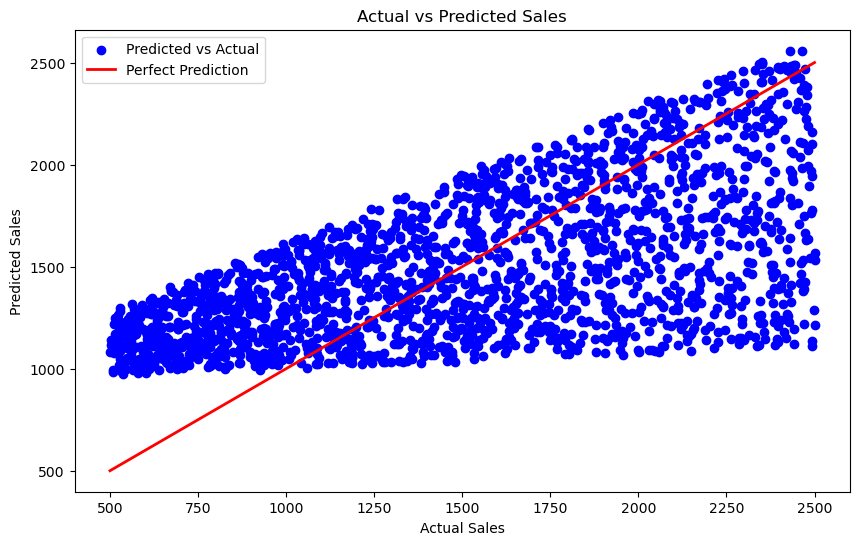

In [51]:
import matplotlib.pyplot as plt

# Plotting Actual vs Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, final_predictions, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()


In [53]:
# Model performance summary
print("Model Performance Summary:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared: {r2}")


Model Performance Summary:
Mean Absolute Error (MAE): 379.04703385238804
Mean Squared Error (MSE): 212738.44106875523
R-squared: 0.35497959533532764
